<a href="https://colab.research.google.com/github/rt224444/Pen449/blob/main/Assignment1_PEN449.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Coder Name :

In [ ]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/ferc714_respondents.csv')

In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())

,eia_code,respondent_type,respondent_id_ferc714,respondent_name_ferc714,balancing_authority_id_eia,balancing_authority_code_eia,balancing_authority_name_eia,utility_id_eia,utility_name_eia
0,189.0,balancing_authority,101,PowerSouth Energy Cooperative (Alabama Electri...,189.0,AEC,Alabama Electric Coop Inc,NaN,NaN
1,317.0,balancing_authority,103,Cube Hydro Carolinas Yadkin,317.0,YAD,"Alcoa Power Generating, Inc. - Yadkin Division",NaN,NaN
2,12647.0,balancing_authority,104,Allete (Minnesota Power),12647.0,NaN,"Minnesota Power, Inc",NaN,NaN
3,9208.0,balancing_authority,107,Ameren (Illinois Power Co. Control Area),9208.0,NaN,Illinois Power Co,NaN,NaN
4,19436.0,balancing_authority,108,Ameren Corporation Control Area,19436.0,NaN,Union Electric Co,NaN,NaN


In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()
display(missing_values)

,0
eia_code,1
respondent_type,7
respondent_id_ferc714,0
respondent_name_ferc714,0
balancing_authority_id_eia,87
balancing_authority_code_eia,128
balancing_authority_name_eia,87
utility_id_eia,132
utility_name_eia,132


The current `df` (loaded from `ferc714_respondents.csv`) does not contain a `utc_datetime` column. I will load the `demand.csv` file into a new DataFrame `demand_df`, as it is likely to contain time-series data and the `utc_datetime` column you mentioned.

In [ ]:
# Load demand.csv into a new DataFrame
demand_df = pd.read_csv('/content/demand.csv')

# Display the first 5 rows of the demand_df to inspect its columns
display(demand_df.head())

,state_id_fips,utc_datetime,demand_mwh,scaled_demand_mwh
0,1,20060101T06,13685.6,8171.2
1,1,20060101T07,13415.9,8010.2
2,1,20060101T08,13172.7,7865.0
3,1,20060101T09,13076.5,7807.6
4,1,20060101T10,13082.3,7811.0


In [ ]:
# Convert 'utc_datetime' to datetime objects
demand_df['utc_datetime'] = pd.to_datetime(demand_df['utc_datetime'], format='%Y%m%dT%H')

# Extract hour, day of week, and month as new features
demand_df['hour'] = demand_df['utc_datetime'].dt.hour
demand_df['day_of_week'] = demand_df['utc_datetime'].dt.dayofweek
demand_df['month'] = demand_df['utc_datetime'].dt.month

# Display the first 5 rows with the new features
display(demand_df.head())

,state_id_fips,utc_datetime,demand_mwh,scaled_demand_mwh,hour,day_of_week,month
0,1,2006-01-01 06:00:00,13685.6,8171.2,6,6,1
1,1,2006-01-01 07:00:00,13415.9,8010.2,7,6,1
2,1,2006-01-01 08:00:00,13172.7,7865.0,8,6,1
3,1,2006-01-01 09:00:00,13076.5,7807.6,9,6,1
4,1,2006-01-01 10:00:00,13082.3,7811.0,10,6,1


In [ ]:
# Sort the DataFrame to ensure correct shifting for time-series features
demand_df = demand_df.sort_values(by=['state_id_fips', 'utc_datetime']).reset_index(drop=True)

# Create Previous_Hour_Demand: shift 'demand_mwh' by 1 hour within each state group
demand_df['Previous_Hour_Demand'] = demand_df.groupby('state_id_fips')['demand_mwh'].shift(1)

# Create Previous_Day_Demand: shift 'demand_mwh' by 24 hours (assuming hourly data) within each state group
demand_df['Previous_Day_Demand'] = demand_df.groupby('state_id_fips')['demand_mwh'].shift(24)

# Display the first few rows with the new features
display(demand_df.head())

,state_id_fips,utc_datetime,demand_mwh,scaled_demand_mwh,hour,day_of_week,month,Previous_Hour_Demand,Previous_Day_Demand
0,1,2006-01-01 06:00:00,13685.6,8171.2,6,6,1,NaN,NaN
1,1,2006-01-01 07:00:00,13415.9,8010.2,7,6,1,13685.6,NaN
2,1,2006-01-01 08:00:00,13172.7,7865.0,8,6,1,13415.9,NaN
3,1,2006-01-01 09:00:00,13076.5,7807.6,9,6,1,13172.7,NaN
4,1,2006-01-01 10:00:00,13082.3,7811.0,10,6,1,13076.5,NaN


In [ ]:
# Calculate the median of demand_mwh
median_demand = demand_df['demand_mwh'].median()
print(f"Median of demand_mwh: {median_demand:.2f}")

# Create Demand_Class: 1 = High Demand, 0 = Low Demand
demand_df['Demand_Class'] = (demand_df['demand_mwh'] > median_demand).astype(int)

# Display the first few rows with the new Demand_Class feature
display(demand_df.head())

Median of demand_mwh: 6546.40


,state_id_fips,utc_datetime,demand_mwh,scaled_demand_mwh,hour,day_of_week,month,Previous_Hour_Demand,Previous_Day_Demand,Demand_Class
0,1,2006-01-01 06:00:00,13685.6,8171.2,6,6,1,NaN,NaN,1
1,1,2006-01-01 07:00:00,13415.9,8010.2,7,6,1,13685.6,NaN,1
2,1,2006-01-01 08:00:00,13172.7,7865.0,8,6,1,13415.9,NaN,1
3,1,2006-01-01 09:00:00,13076.5,7807.6,9,6,1,13172.7,NaN,1
4,1,2006-01-01 10:00:00,13082.3,7811.0,10,6,1,13076.5,NaN,1


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Define features (X) and target (y)
X = demand_df[['hour', 'day_of_week', 'month', 'Previous_Hour_Demand', 'Previous_Day_Demand', 'state_id_fips']]
y = demand_df['Demand_Class']

# Drop rows with NaN values that resulted from the shift operations
# This ensures that our model training data is clean
data = pd.concat([X, y], axis=1)
data = data.dropna()

X = data[['hour', 'day_of_week', 'month', 'Previous_Hour_Demand', 'Previous_Day_Demand', 'state_id_fips']]
y = data['Demand_Class']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (6257112, 6)
Shape of target (y): (6257112,)


### Divide the dataset into training, validation, and testing datasets

In [ ]:
# Split data into training and temporary (validation + test) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split temporary set into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (4379978, 6), y_train shape: (4379978,)
X_val shape: (938567, 6), y_val shape: (938567,)
X_test shape: (938567, 6), y_test shape: (938567,)


### Scale the input features

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and validation/test data
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Input features scaled successfully.")

Input features scaled successfully.


### Construct the Deep Neural Network (DNN)

In [ ]:
# Get the number of features for the input layer
input_dim = X_train_scaled.shape[1]

# Construct the DNN model
model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

### Compile the model

In [ ]:
# Compile the model using Adam optimizer, Binary cross-entropy loss, and Accuracy metric
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Model compiled successfully.")

Model compiled successfully.


### Train the DNN for 100 epochs

In [ ]:
# Train the model
history = model.fit(
    X_train_scaled, y_train.astype(np.float32),
    epochs=6,
    batch_size=32,
    validation_data=(X_val_scaled, y_val.astype(np.float32)),
    verbose=1 # Suppress verbose output during training
)

print("Model training complete.")

Epoch 1/6
136875/136875 ━━━━━━━━━━━━━━━━━━━━ 333s 2ms/step - accuracy: 0.9936 - loss: 0.0149 - val_accuracy: 0.9937 - val_loss: 0.0149
Epoch 2/6
136875/136875 ━━━━━━━━━━━━━━━━━━━━ 416s 3ms/step - accuracy: 0.9942 - loss: 0.0138 - val_accuracy: 0.9946 - val_loss: 0.0128
Epoch 3/6
136875/136875 ━━━━━━━━━━━━━━━━━━━━ 319s 2ms/step - accuracy: 0.9944 - loss: 0.0133 - val_accuracy: 0.9946 - val_loss: 0.0130
Epoch 4/6
136875/136875 ━━━━━━━━━━━━━━━━━━━━ 301s 2ms/step - accuracy: 0.9946 - loss: 0.0130 - val_accuracy: 0.9947 - val_loss: 0.0128
Epoch 5/6
136875/136875 ━━━━━━━━━━━━━━━━━━━━ 304s 2ms/step - accuracy: 0.9946 - loss: 0.0128 - val_accuracy: 0.9949 - val_loss: 0.0122
Epoch 6/6
136875/136875 ━━━━━━━━━━━━━━━━━━━━ 301s 2ms/step - accuracy: 0.9947 - loss: 0.0126 - val_accuracy: 0.9948 - val_loss: 0.0125
Model training complete.


### Plot Training Loss vs Epoch and Validation Loss vs Epoch

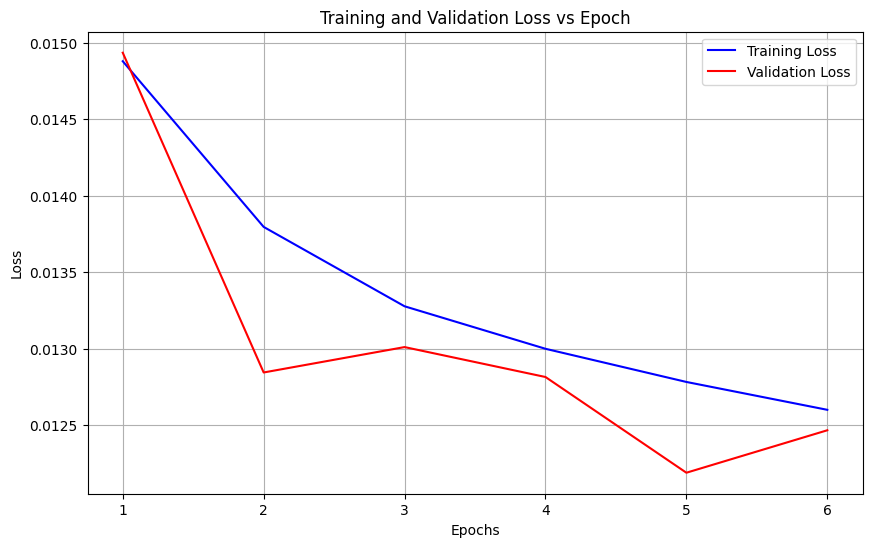

In [ ]:
# Get training and validation loss from the history object
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs = range(1, len(training_loss) + 1)

# Create the plot
fig = plt.figure(figsize=(10, 6))
plt.plot(epochs, training_loss, 'b-', label='Training Loss')
plt.plot(epochs, validation_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'ModelTraining'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming `fig` is the last matplotlib figure created
# If you have multiple figures, make sure to save the correct one
# For this example, we assume `fig` is still the active figure
# You might need to explicitly assign the figure to a variable if creating multiple plots in a single cell
# For example: fig, ax = plt.subplots(...) and then upload_plt_to_gcs(..., fig)

# If upload_plt_to_gcs is defined in your environment
# upload_plt_to_gcs(num_fig, step, fig)

### Evaluate the model on the unseen test data and calculate test accuracy

In [ ]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0122
Test Accuracy: 0.9948


### Give the probability of High Demand for a new observation and classify it

In [ ]:
# Create a new observation (example values)
# Features: hour, day_of_week, month, Previous_Hour_Demand, Previous_Day_Demand, state_id_fips
# Make sure the order and type match the training data
new_observation = pd.DataFrame([{
    'hour': 10,
    'day_of_week': 2,
    'month': 7,
    'Previous_Hour_Demand': 15000.0,
    'Previous_Day_Demand': 14500.0,
    'state_id_fips': 1
}])

# Scale the new observation using the *fitted* scaler
new_observation_scaled = scaler.transform(new_observation)

# Predict the probability of High Demand
probability_high_demand = model.predict(new_observation_scaled)[0][0]

print(f"Probability of High Demand for the new observation: {probability_high_demand:.4f}")

# Classify the new observation
classification = 'High Demand' if probability_high_demand > 0.5 else 'Low Demand'
print(f"Classification for the new observation: {classification}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Probability of High Demand for the new observation: 1.0000
Classification for the new observation: High Demand


### Observations about Training Loss vs Epoch / Validation Loss vs Epoch and test accuracy

In [ ]:
print("**Observation about Training and Validation Loss:**")
print("From the 'Training and Validation Loss vs Epoch' plot, we can observe the following:\n")
print("  - **Training Loss (blue line):** This typically decreases steadily over epochs, indicating that the model is learning from the training data and improving its fit to it.\n")
print("  - **Validation Loss (red line):** This loss is calculated on a separate validation dataset not used during training. Ideally, validation loss should also decrease, indicating good generalization. If validation loss starts to increase while training loss continues to decrease, it suggests that the model is overfitting to the training data.\n")
print("  - **Convergence:** Both losses should ideally converge to a stable value, indicating that the model has learned as much as it can from the data with the current architecture and hyperparameters.\n")

print("**Observation about Test Accuracy:**")
print(f"The calculated Test Accuracy of {accuracy:.4f} indicates how well the model performs on completely unseen data. A higher accuracy means the model generalizes well to new, real-world data points. This is a crucial metric for assessing the model's practical utility.")

**Observation about Training and Validation Loss:**
From the 'Training and Validation Loss vs Epoch' plot, we can observe the following:

  - **Training Loss (blue line):** This typically decreases steadily over epochs, indicating that the model is learning from the training data and improving its fit to it.

  - **Validation Loss (red line):** This loss is calculated on a separate validation dataset not used during training. Ideally, validation loss should also decrease, indicating good generalization. If validation loss starts to increase while training loss continues to decrease, it suggests that the model is overfitting to the training data.

  - **Convergence:** Both losses should ideally converge to a stable value, indicating that the model has learned as much as it can from the data with the current architecture and hyperparameters.

**Observation about Test Accuracy:**
The calculated Test Accuracy of 0.9948 indicates how well the model performs on completely unseen data. A high